In [61]:
import pandas as pd

df = pd.read_csv("../dataset/Food_Data_Original.csv")

In [62]:
df.head()

,food_item,energy_kcal,carbs,protein_g,fat_g,free_sugar_g,fibre_g,cholesterol_mg,calcium_mg
0,Butternaan,300.0,50.0,7.0,10.0,2.0,2.0,15.0,50.0
1,Cupcake,200.0,30.0,2.0,8.0,20.0,0.5,20.0,20.0
2,Donuts,250.0,30.0,3.0,12.0,10.0,1.0,20.0,20.0
3,French Fries,312.0,41.0,3.4,15.0,0.3,3.8,0.0,20.0
4,Garlic Bread,200.0,25.0,4.0,10.0,1.0,1.0,10.0,30.0


In [63]:
from sklearn.preprocessing import StandardScaler

positive_cols = [
    "protein_g",
    "fibre_g",
    "calcium_mg"
]

negative_cols = [
    "free_sugar_g",
    "fat_g",
    "energy_kcal",
    "cholesterol_mg"
]

cols = positive_cols + negative_cols

scaled = StandardScaler().fit_transform(df[cols])
scaled_df = pd.DataFrame(scaled, columns=cols)

df["nutrition_density"] = (
    0.35 * scaled_df["protein_g"] +
    0.35 * scaled_df["fibre_g"] +
    0.15 * scaled_df["calcium_mg"]
    -
    0.10 * scaled_df["free_sugar_g"]
    -
    0.03 * scaled_df["fat_g"]
    -
    0.01 * scaled_df["energy_kcal"]
    -
    0.01 * scaled_df["cholesterol_mg"]
)

In [64]:
df["health_risk_score"] = (
    0.40 * scaled_df["free_sugar_g"] +
    0.25 * scaled_df["fat_g"] +
    0.15 * scaled_df["energy_kcal"] +
    0.10 * scaled_df["cholesterol_mg"]
    -
    0.05 * scaled_df["protein_g"]
    -
    0.05 * scaled_df["fibre_g"]
)

In [65]:
from sklearn.preprocessing import MinMaxScaler

df["nutrition_density"] = MinMaxScaler((0,100)).fit_transform(
    df[["nutrition_density"]]
)

df["health_risk_score"] = MinMaxScaler((0,100)).fit_transform(
    df[["health_risk_score"]]
)

In [66]:
df.sort_values("health_risk_score", ascending=True)

,food_item,energy_kcal,carbs,protein_g,fat_g,free_sugar_g,fibre_g,cholesterol_mg,calcium_mg,nutrition_density,health_risk_score
1006,Rasam powder (Rasam masala),267.96,25.19,12.04,11.80,1.91,35.71,0.00,562.15,100.000000,0.000000
1003,Garam masala,254.21,26.20,9.89,10.97,1.79,35.56,0.00,609.77,98.353266,0.236055
1007,Sambar powder (Sambar masala),297.46,23.38,12.50,15.58,1.87,34.56,0.00,439.95,95.047023,2.321146
697,Gun powder chutney,312.34,47.65,21.55,2.67,1.16,13.95,0.00,68.87,62.255239,4.386540
891,Pav bhaji masala,230.47,29.15,9.13,10.96,1.48,24.30,0.00,588.91,78.123475,5.425733
...,...,...,...,...,...,...,...,...,...,...,...
857,Mango murabba candy,293.35,77.32,0.27,0.05,74.73,0.95,0.00,16.55,3.488259,84.841459
732,Chocolate butter icing,469.59,61.72,3.21,24.77,59.82,0.00,54.90,31.87,7.040944,86.497984
966,Royal icing,332.58,86.53,1.74,0.02,85.57,0.00,0.00,2.87,2.269209,95.425140
965,Glace icing,323.51,86.31,0.01,0.01,85.35,0.00,0.00,1.95,0.000000,95.712691


<Axes: >

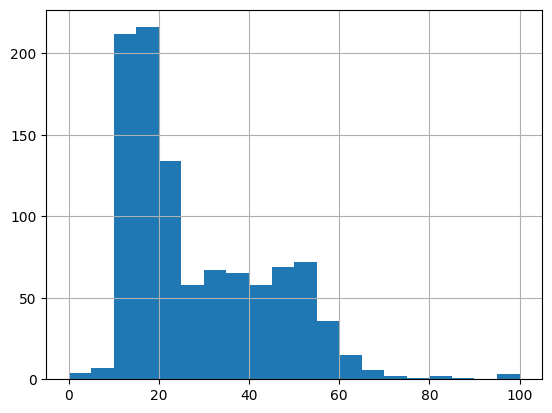

In [67]:
df["health_risk_score"].hist(bins=20)

In [68]:
df['nutrition_density'].describe()

count    1028.000000
mean       18.995405
std         8.766681
min         0.000000
25%        13.796197
50%        17.420249
75%        22.736434
max       100.000000
Name: nutrition_density, dtype: float64

In [69]:
spices = [
    'Garam masala',
    'Chat masala',
    'Kashmiri masala',
    'Pav bhaji masala',
    'Rasam powder (Rasam masala)',
    'Sambar powder (Sambar masala)',
    'Bengal 5 Spice Blend (Panch Phoran)',
    'Gun powder chutney'
]

df['is_spice_condiment'] = df['food_item'].isin(spices)

In [70]:
df.columns

Index(['food_item', 'energy_kcal', 'carbs', 'protein_g', 'fat_g',
       'free_sugar_g', 'fibre_g', 'cholesterol_mg', 'calcium_mg',
       'nutrition_density', 'health_risk_score', 'is_spice_condiment'],
      dtype='object')

In [71]:
#Connect to MySQL\
from sqlalchemy import create_engine

engine = create_engine(
    "mysql+pymysql://root:@localhost:3306/food_health_analysis"
)

connection = engine.connect()

print("Connected successfully!")

Connected successfully!


In [72]:
df.to_sql(
    name="nutrition",
    con=engine,
    if_exists="replace",
    index=False
)

print("Data uploaded successfully!")

Data uploaded successfully!
